# Adam (Adaptive Moment Estimation)

## Adam is just the two things we already built, combined

In the previous notebooks we saw two separate fixes:
- **Momentum** — a velocity (EMA of gradients) that smooths the direction and kills the zigzag.
- **Adaptive learning rates (RMSprop)** — a per-weight step size (EMA of *squared* gradients)
  that shrinks steep directions and boosts gentle ones.

**Adam runs BOTH at the same time:**

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\,\nabla L \quad\text{← momentum half (1st moment)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)\,\nabla L^2 \quad\text{← adaptive half (2nd moment)}$$
$$w \leftarrow w - \eta \cdot \frac{m_t}{\sqrt{v_t}+\epsilon}$$

- The **numerator (m)** is the momentum/smoothed direction (from the momentum notebook).
- The **denominator (√v)** is the per-weight adaptive scaling (from the RMSprop notebook).
- **β₁≈0.9, β₂≈0.999, ε≈1e-8** — standard defaults you rarely change.
- A small **bias correction** (m̂, v̂) fixes the estimates in the first few steps.

So Adam fixes **both** problems at once: the zigzag (momentum) *and* the learning-rate
mismatch across directions (adaptive).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Same narrow valley as the momentum & adaptive notebooks
def loss(w): return w[0]**2 + 20*w[1]**2
def grad(w): return np.array([2*w[0], 40*w[1]])

start = np.array([9.0, 1.0]); steps = 60

def plain_gd(eta):
    w=start.copy(); path=[w.copy()]
    for _ in range(steps): w=w-eta*grad(w); path.append(w.copy())
    return np.array(path)

def momentum_gd(eta, beta=0.9):
    w=start.copy(); v=np.zeros(2); path=[w.copy()]
    for _ in range(steps): v=beta*v+grad(w); w=w-eta*v; path.append(w.copy())
    return np.array(path)

def rmsprop(eta, beta=0.9, eps=1e-8):
    w=start.copy(); G=np.zeros(2); path=[w.copy()]
    for _ in range(steps):
        g=grad(w); G=beta*G+(1-beta)*g**2
        w=w-eta*g/(np.sqrt(G)+eps); path.append(w.copy())
    return np.array(path)

def adam(eta, b1=0.9, b2=0.999, eps=1e-8):
    w=start.copy(); m=np.zeros(2); v=np.zeros(2); path=[w.copy()]
    for t in range(1, steps+1):
        g=grad(w)
        m = b1*m + (1-b1)*g          # momentum half
        v = b2*v + (1-b2)*g**2       # adaptive half
        m_hat = m/(1-b1**t)          # bias correction
        v_hat = v/(1-b2**t)
        w = w - eta*m_hat/(np.sqrt(v_hat)+eps)
        path.append(w.copy())
    return np.array(path)

p_plain=plain_gd(0.02); p_mom=momentum_gd(0.008); p_rms=rmsprop(0.1); p_adam=adam(0.3)

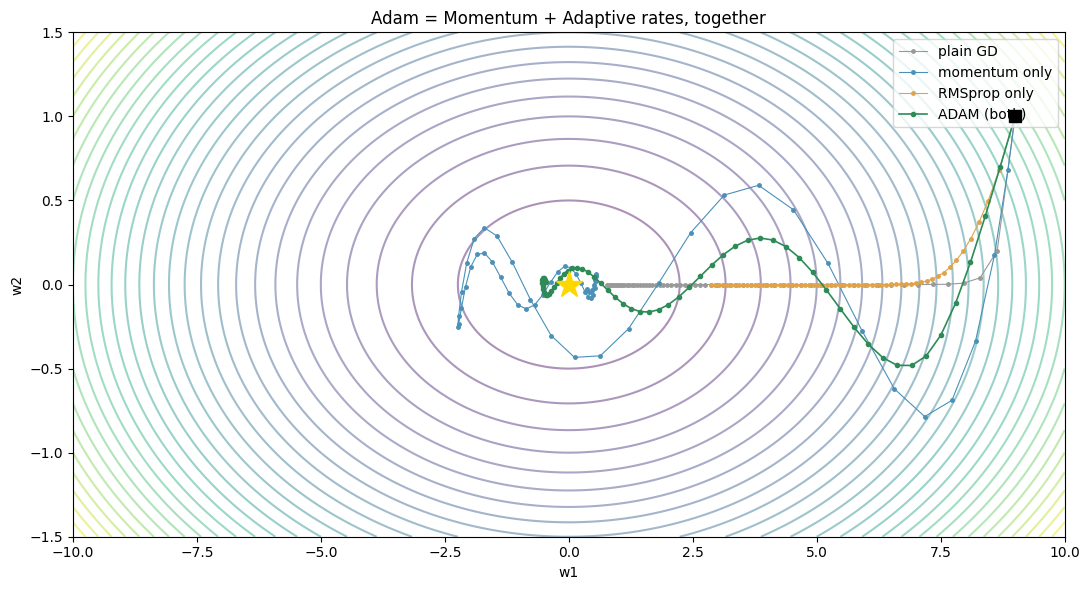

Final loss after 60 steps:
  plain GD  : 0.60399
  momentum  : 0.14592
  RMSprop   : 8.21560
  ADAM      : 0.21263


In [2]:
w1=np.linspace(-10,10,400); w2=np.linspace(-1.5,1.5,400)
W1,W2=np.meshgrid(w1,w2); Z=W1**2+20*W2**2

plt.figure(figsize=(11,6))
plt.contour(W1,W2,Z,levels=35,cmap='viridis',alpha=0.45)
plt.plot(p_plain[:,0],p_plain[:,1],'o-',color='#999',ms=2.5,lw=0.8,label='plain GD')
plt.plot(p_mom[:,0], p_mom[:,1], 'o-',color='#4a90b8',ms=2.5,lw=0.8,label='momentum only')
plt.plot(p_rms[:,0], p_rms[:,1], 'o-',color='#e0a34a',ms=2.5,lw=0.8,label='RMSprop only')
plt.plot(p_adam[:,0],p_adam[:,1],'o-',color='#2e8b57',ms=3,lw=1.2,label='ADAM (both)')
plt.plot(0,0,'*',color='gold',markersize=20,zorder=6); plt.plot(*start,'s',color='k',markersize=9,zorder=6)
plt.title('Adam = Momentum + Adaptive rates, together')
plt.xlabel('w1'); plt.ylabel('w2'); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()

print("Final loss after", steps, "steps:")
for name,p in [('plain GD',p_plain),('momentum',p_mom),('RMSprop',p_rms),('ADAM',p_adam)]:
    print(f"  {name:10s}: {loss(p[-1]):.5f}")

## Takeaway

**Adam combines the two tools from the previous notebooks:**
- the **momentum** velocity (numerator) — smooths direction, kills zigzag
- the **adaptive** per-weight scaling (denominator, from RMSprop) — right-sizes each weight's step

**In practice, Adam runs on top of mini-batch gradient descent** — mini-batch decides *how
much data per step*, Adam decides *how to step smartly*. This combination —
**mini-batch + Adam (or AdamW)** — is the **go-to optimization technique for ~90% of deep
learning and fine-tuning.** You almost never write it by hand:

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

The β₁, β₂, ε have solid defaults; the main knob you tune is the **learning rate**.

*Note: exact final-loss numbers here depend on each method's learning rate (not perfectly
tuned for a fair race) — the point is the **combination**, not a leaderboard. On real,
messy problems Adam's robustness is why it's the default.*